In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
dataset = pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv', header=1) #So header=1 tells pandas: "the real column names are on row index 1, not row 0."
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [3]:
## INFORMATION 
dataset.info()
#dataset.info() is important because it gives a quick summary of your data structure—showing the number of rows,
#columns, data types, and missing values—so you can identify cleaning steps 
# (like fixing data types or handling nulls) before analysis or modeling.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


## DATA CLEANING

In [4]:
### DATA CLEANING 
dataset[dataset.isnull().any(axis=1)]
# axis=1 checks each row — Returns: does this row contain at least one missing value?
#dataset[dataset.isnull().any(axis = 1)]is used to filter and display only the rows that contain missing values.

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [5]:
df = dataset
df.loc[:122, "Region"]=0 # Assign 0 (Bejaia) to rows from index 0 up to 122 (inclusive)
df.loc[122:, "Region"]=1 # Assign 1 (Sidi-Bel Abbes) to rows from index 122 to the end
# ⚠️ Note: index 122 gets overwritten here (becomes 1)

In [6]:
df.info()
# checking whether our new feature has been added

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.0+ KB


In [10]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [11]:
df['Region'] = df['Region'].astype(int) # Convert the Region column from float64 to integer (0 and 1)
df.head()
## checking whether our new feature is added i.e Region

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [14]:
df.isnull().sum()
# Check the total number of missing values in each column
# to decide which columns need cleaning before modelling

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [15]:
## REMOVING THE NULL VALUES
df = df.dropna().reset_index(drop=True)
#df = df.dropna(); Remove all (entire) rows that contain at least one missing (NaN) value

# .reset_index; Reset the index back to a clean continuous sequence (0, 1, 2, 3...)
# because after dropna() the index has gaps where rows were deleted
# e.g. index jumps from 121 → 123 (skipping the dropped row 122)

#drop = True; Prevent the old broken index from being saved as a new column in the dataframe
# without drop=True, the old index (0,1,121,123...) becomes its own column



In [16]:
df.isnull().sum() ## checking whether null values still exist 

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [17]:
df.iloc[[122]]
# Inspect row at position 122 to confirm it is the duplicate header row
# (day, month, year, Temperature...) that was read as data instead of a header
# This is the junk row from the Sidi-Bel Abbes region label in the raw CSV

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [18]:
df = df.drop(122).reset_index(drop=True) # removing the 122nd row
# Drop the junk header row at index 122 and reset to a clean continuous index

In [19]:
df.iloc[[122]] ## confirming the changes for the 122nd row

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [20]:
df.columns # Check all column names to inspect for any formatting issues such as leading spaces (' RH', ' Ws'), 
#trailing spaces ('Rain ', 'Classes ') which would cause KeyError when trying to access those columns late

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [21]:
## fixing spaces in column names 
df.columns = df.columns.str.strip()
# .str         → accessor that allows string methods to be applied to every column name at once
# .strip()     → removes leading and trailing spaces from each column name

df.columns ## confirming the columns 

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


## changing the required columns as interger data type

In [23]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [24]:
df[['month','day','year','Temperature','RH','Ws']]=df[['month','day','year','Temperature','RH','Ws']].astype(int)

In [25]:
df.info()
# Verify the dtype changes were applied successfully
# month, day, year, Temperature, RH, Ws should now show int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4   RH           243 non-null    int64 
 5   Ws           243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


# Changing the other columns to float data datatype

In [26]:
objects=[features for features in df.columns if df[features].dtypes=='O'] 
# Find all columns that are still object dtype — these need to be converted

objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [27]:
for i in objects:
    if i!='Classes':
        df[i]=df[i].astype(float)


# Loop through each object column and convert to float
# skipping Classes since it is a categorical label (fire/not fire) not a number

In [28]:
df.info() ## verifying 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [29]:
df.describe()
# Generate summary statistics for all numeric columns to understand
# the distribution, spread, and range of each feature
# Reveals: count, mean, std, min, 25%, 50%, 75%, max

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [43]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [44]:
## Let save the cleaned dataset
df.to_csv("Algerian_forest_fires_cleaned_dataset.csv", index=False)
# Save the cleaned DataFrame as a new CSV file without including row index numbers
# index=False prevents pandas from writing the row numbers (0,1,2...)
# as an extra column in the saved file

## Exploratory Data Analysis

In [45]:
df_copy = df.drop(['day', 'month', 'year'], axis=1) ## dropping day month and year
# Remove date-related columns since they may not significantly contribute
# to the analysis/model and to simplify the dataset for EDA and modeling
# axis=1 specifies we are dropping columns not rows

In [46]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [47]:
#NB:The column Classes is not remove bcos If you are probably solving a classification problem, you have to probably keep this classes 
# as your dependent feature because it represents the target labels (Fire or Not Fire) that the model is trying to predict.

In [48]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [49]:
## Encoding of the categories in classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)
# np.where checks each row — if 'not fire' is found assign 0, otherwise assign 1

#.str.contains('not fire') Checks each value in the 'Classes' column to see if it contains the text 'not fire'
# Returns True or False

#np.where(...)
# Applies a condition: If condition is True → assign 0
# Else → assign 1

In [50]:
## categories in classes
df_copy['Classes'].value_counts()

## Verify the encoding worked correctly
# value_counts() shows how many 0s and 1s exist after encoding

Classes
1    137
0    106
Name: count, dtype: int64

In [51]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [52]:
print(plt.style.available)
# Check all valid style names available on the current matplotlib version
# necessary because style names changed in matplotlib 3.6+
# e.g. 'seaborn' no longer works — must use 'seaborn-v0_8' instead

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


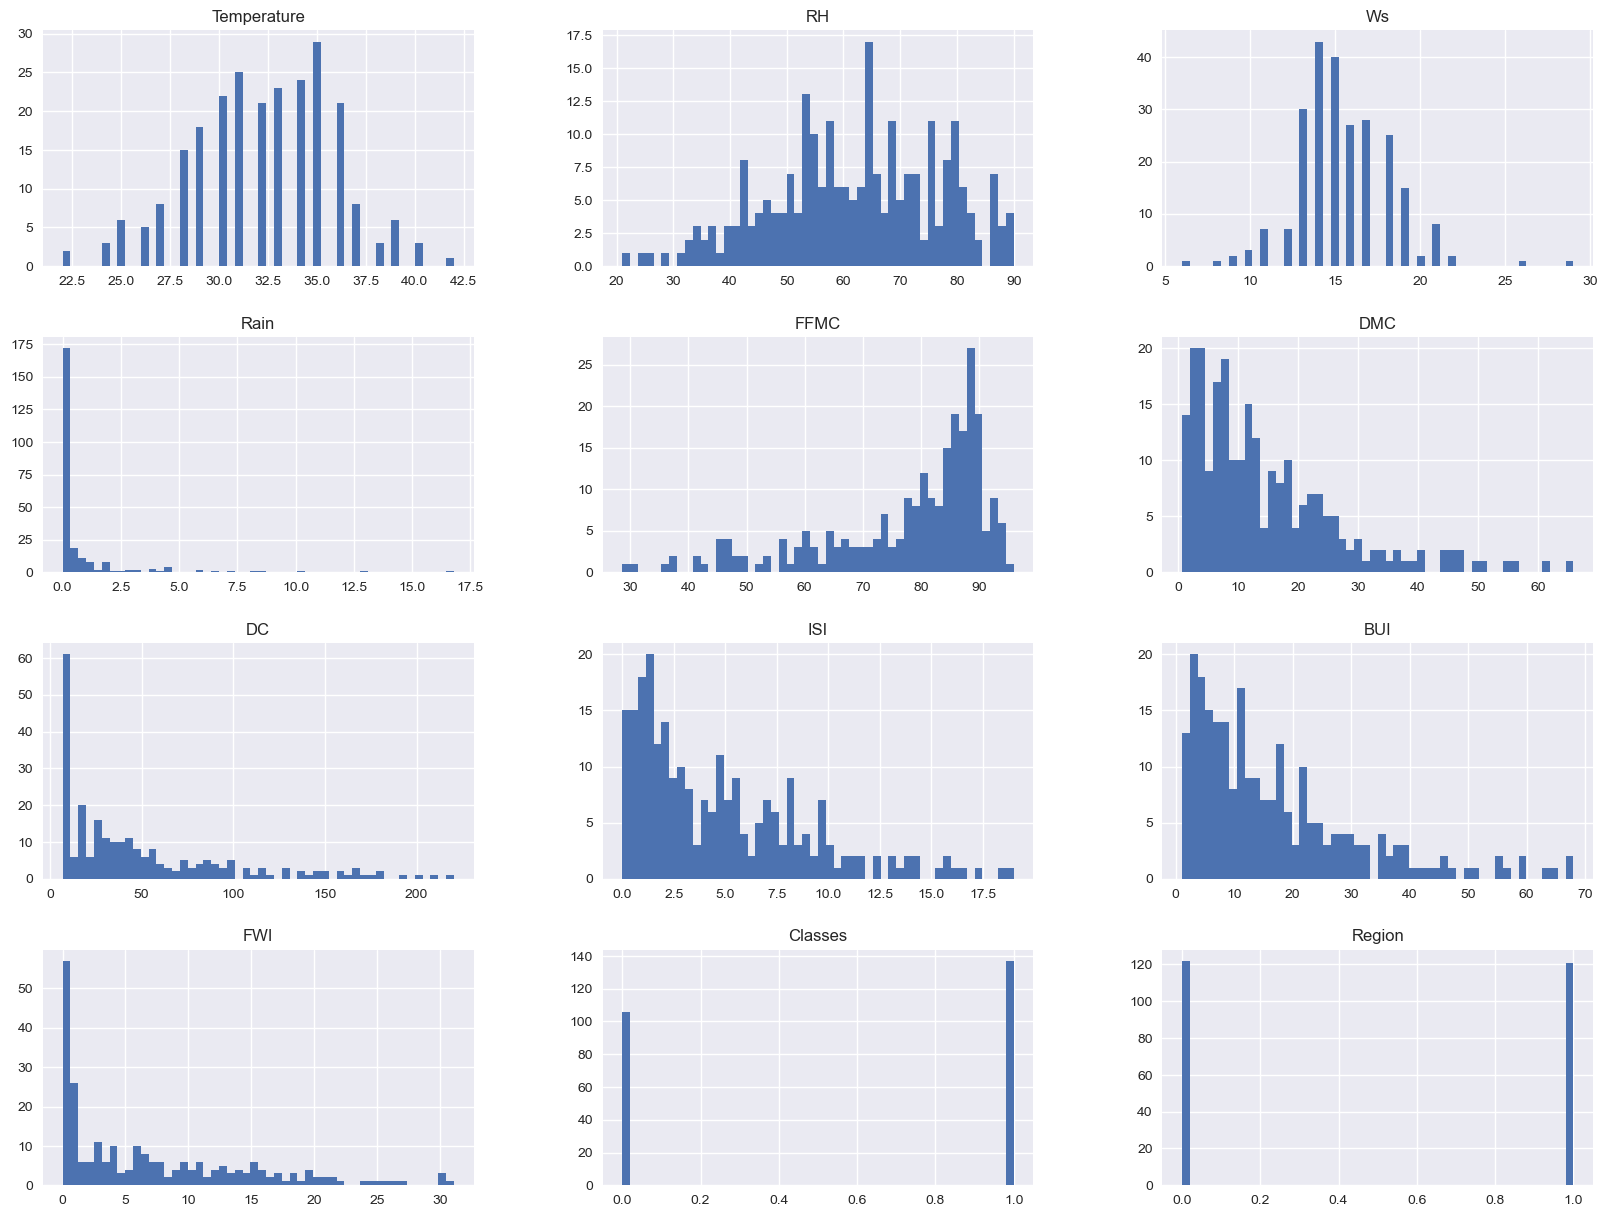

In [53]:
## Plot density plot for all features
plt.style.use('seaborn-v0_8') # seaborn-v0_8 applies a clean seaborn visual style to the matplotlib plots

df_copy.hist(bins=50, figsize=(20, 15))
# Plot a histogram for every numeric column in df_copy simultaneously
# bins=50 → divides each feature's range into 50 bars for detailed distribution view
# figsize=(20,15) → sets the figure wide and tall enough to display all plots clearly

plt.show()

In [54]:
## Percentage for Pie chart
percentage = df_copy['Classes'].value_counts(normalize=True)*100 
percentage
## Calculate percentage of each class for Pie chart
# value_counts() → counts occurrences of each unique value (1=fire, 0=not fire)
# normalize=True → converts raw counts into proportions (0 to 1)
# *100           → converts proportions into percentages (0 to 100)

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

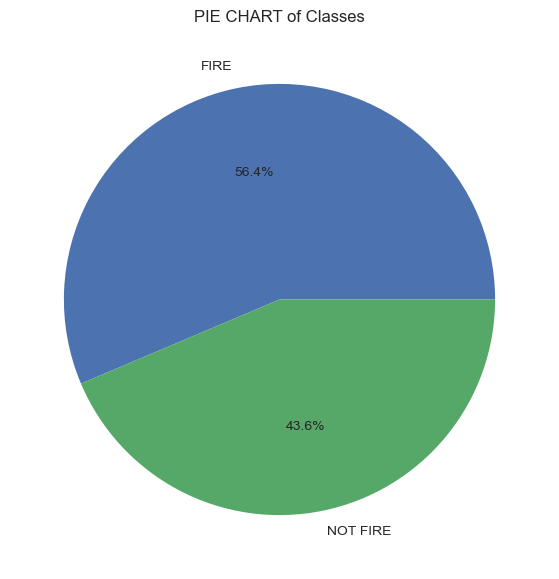

In [55]:
## Plotting piechart
classlabels = ["FIRE", "NOT FIRE"] # Defining the labels for each slice of the pie
plt.figure(figsize=(12,7))
plt.pie(percentage, labels=classlabels, autopct='%1.1f%%')
# Plot the pie chart using the precomputed percentages
# percentage  → the values for each slice (56.4% fire, 43.6% not fire)
# labels      → assigns "FIRE" and "NOT FIRE" as slice labels
# autopct     → displays the percentage value on each slice
#               %1.1f%% → 1 decimal place e.g. 56.4%
plt.title("PIE CHART of Classes")
plt.show()

In [56]:
df_copy.corr() ## correlation btn all the features

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


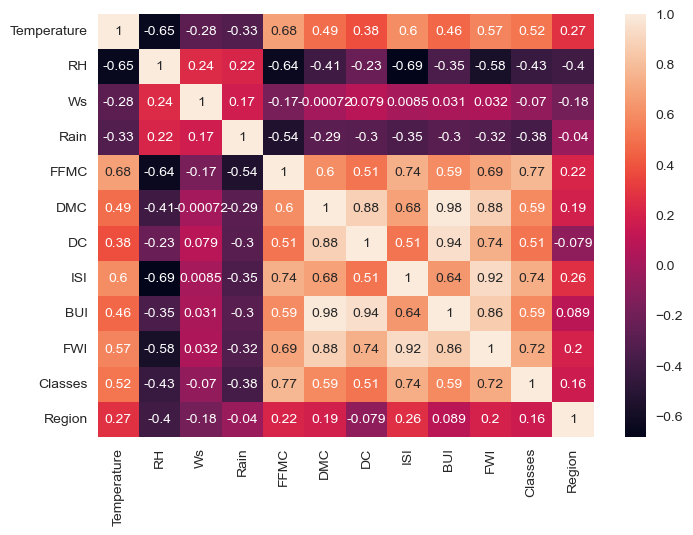

In [60]:
sns.heatmap(df_copy.corr(), annot=True) # Visualize the correlation matrix as a color coded heatmap
# making it much easier to spot strong and weak relationships
plt.show()

# NB: # Light/White  → strong positive correlation (close to 1.0)  
    # Dark Purple  → strong negative correlation (close to -1.0) 
    # Mid Pink     → moderate correlation
    # Dark Black   → weak or no correlation

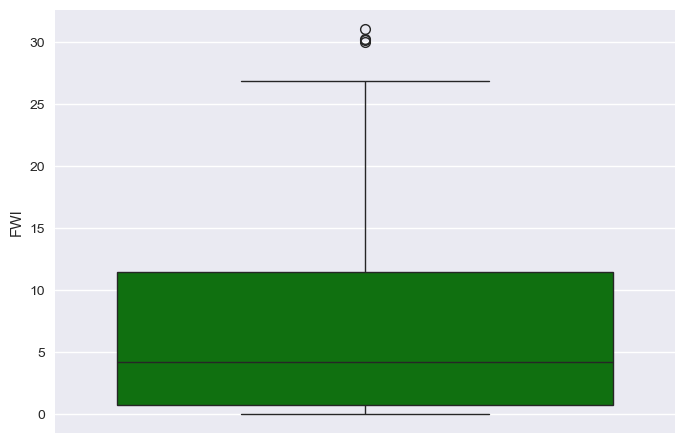

In [61]:
## Box plots 
sns.boxplot(df_copy['FWI'], color='green')
## Box plot to visualize the distribution and outliers of FWI (target variable)
# shows the spread, median, quartiles and outliers in one plot
plt.show()

In [62]:
## Monthly Fire Analysis
# i'm using the variable df bcos it contains the months (df_copy dropped it earlier)
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire') # # Re-encoding Classes back to text labels for readable plot legend



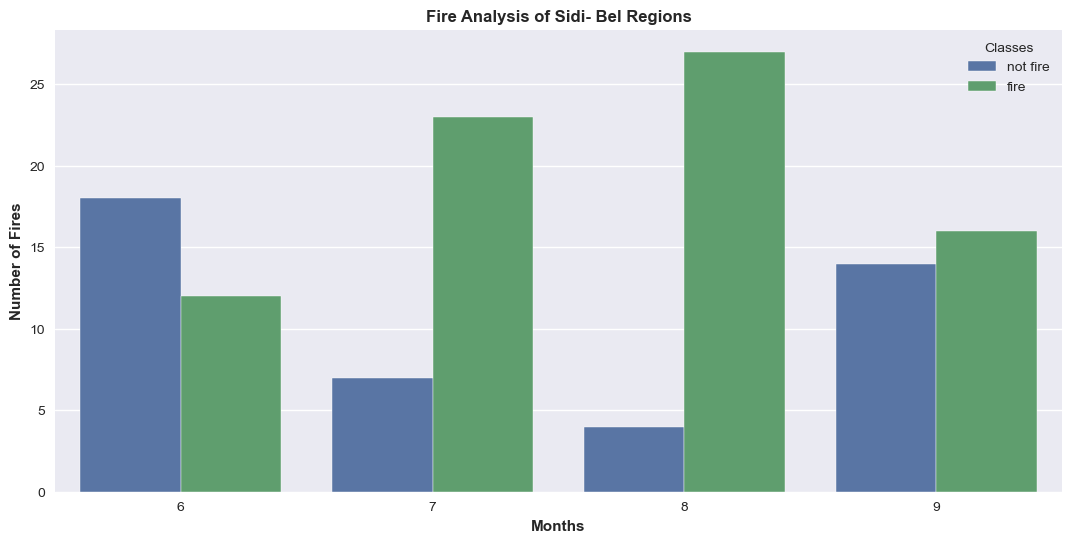

In [63]:
## Monthly Fire Analysis of Sidi- Bel Regions
dftemp=df.loc[df['Region']==1] # Filter df to only Sidi-Bel Abbes rows (Region=1)
plt.subplots(figsize=(13,6)) # creates figure AND axes together
sns.set_style('whitegrid')  # Apply clean white grid style for readability

sns.countplot(x='month',hue='Classes',data=dftemp)
# Count plot — counts occurrences of each month split by fire/not fire class
# x='month'      → x axis shows months (6,7,8,9)
# hue='Classes'  → splits each month bar into fire vs not fire
# data=df        → uses the full df (both regions) as data source

plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi- Bel Regions",weight='bold')
plt.show()

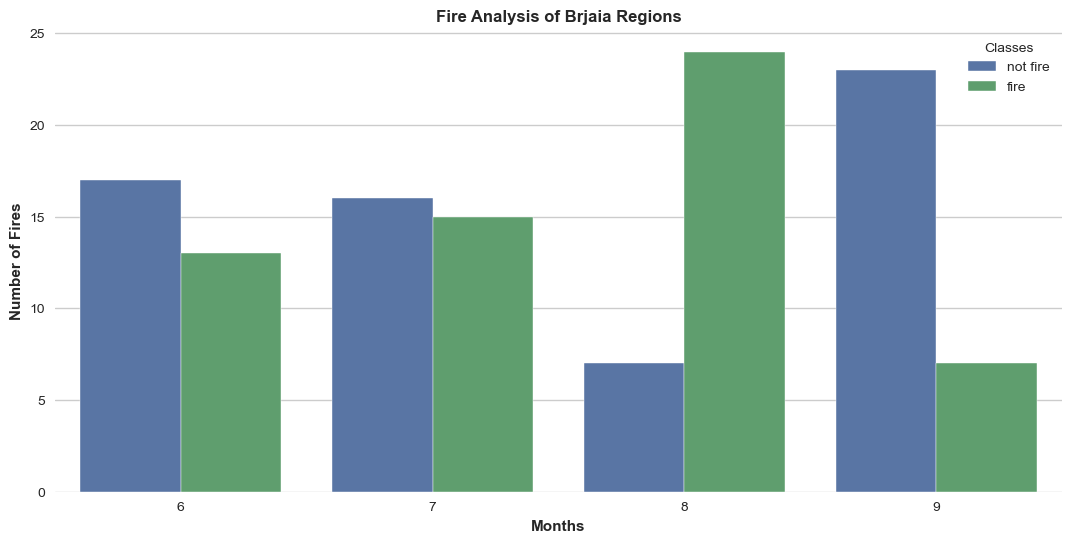

In [64]:
## Monthly Fire Analysis of Brjaia Regions
dftemp=df.loc[df['Region']==0] # Filter df to only Brjaia Regions rows (Region=0)
plt.subplots(figsize=(13,6)) # creates figure AND axes together

sns.set_style('whitegrid') # Apply clean white grid style for readability

sns.countplot(x='month',hue='Classes',data=dftemp)
# Count plot — counts occurrences of each month split by fire/not fire class
# x='month'      → x axis shows months (6,7,8,9)
# hue='Classes'  → splits each month bar into fire vs not fire
# data=df        → uses the full df (both regions) as data source

plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Brjaia Regions",weight='bold')
plt.show()